# Advanced Cloud Clearing in Sentinel-2: combining spectral and clustering approaches

Our goal here is to prepare a Sentinel-2 image over a region of interest and create a cloud-clearing function that uses both:
- Spectral characteristics of clouds (e.g., high reflectance in blue, low in SWIR)
- A clustering algorithm (e.g., k-means or DBSCAN (but do feel free to use whatever you think is best) on pixel features) to find and expand cloud-masked areas to include neighboring “cloudy-ish” pixels.

My intent is that by the end of this lab you have a function that you can then use in many of your project workflows to ensure that the data you are using is as free of clouds as possible (you will need to re-design it if apply to imagery other than Sentinel 2).

The overview of our workflow is to:
- Load and filter on location, date and overall cloud contamination > Sentinel-2 surface reflectance imagery in Earth Engine.
- Apply the s2cloudless cloud probability algorithm.
- Apply a clustering approach to detect “borderline” cloudy pixels near heavy clouds.
- Generate a clean composite for a chosen date range.

We are using this tutorial from Google as the basis of our work: [Sentinel-2 Cloud Masking with s2cloudless](https://developers.google.com/earth-engine/tutorials/community/sentinel-2-s2cloudless).


**As ever, in this lab whenever we ask you for an visual output, we are expecting you to present it to a publication quality level.**


________________________________________________________________________________
# Implementing S2 Cloudless

In [63]:
# Our usual set up routine
!pip install geemap --quiet

import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans

import ee
ee.Authenticate()
ee.Initialize(project='geog761-503611') #<- Remember to change this to your own project's name!

First, let us define our area of interest (AOI) and the cloud mask parameters, here is the table from the Earth Engine Catalogue: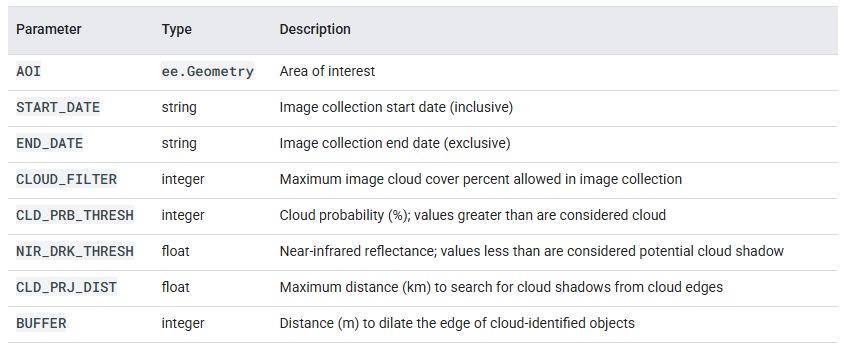

In [64]:
# Control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

Next we use these variables to build a Sentinel 2 image collection. You have done all this before, but now we are using more of the tools at our disposal to get exactly what we want.

Also, from now on we are going to be using functions to make our code more useable and extensible:

In [65]:
def get_s2_sr_cld_col(aoi, start_date, end_date):
    # Import and filter S2 SR.
    s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))

    # Import and filter s2cloudless.
    s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        .filterBounds(aoi)
        .filterDate(start_date, end_date))

    # Join the filtered s2cloudless collection to the SR collection by the 'system:index' property.
    return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(**{
        'primary': s2_sr_col,
        'secondary': s2_cloudless_col,
        'condition': ee.Filter.equals(**{
            'leftField': 'system:index',
            'rightField': 'system:index'
        })
    }))

In [66]:
# Apply the function in order to generate the collection
s2_sr_cld_col_eval = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [67]:
# As ever, a good idea to do a quick viusalization check
Map = geemap.Map(basemap="HYBRID")
Map.centerObject(AOI, 10)
Map.addLayer(s2_sr_cld_col_eval, {'bands':['B4','B3','B2'], 'min':0, 'max':3000}, 'S2 collection (before)')
Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Yup that is pretty cloudy!

Now, we will define a function to add the s2cloudless probability layer and derived cloud mask as bands to an S2 SR image input.

In [68]:
def add_cloud_bands(img):
    # Get s2cloudless image, subset the probability band.
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')

    # Condition s2cloudless by the probability threshold value.
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')

    # Add the cloud probability layer and cloud mask as image bands.
    return img.addBands(ee.Image([cld_prb, is_cloud]))

The next function we need adds bands that adds layers that identify dark pixels, cloud projection, and identified shadows as bands to an S2 SR image input. Note that the image input needs to be the result of the above add_cloud_bands function because it relies on knowing which pixels are considered cloudy (via the renamed 'CLD_PRB_THRESH' band native to this S2 product).

In [69]:
def add_shadow_bands(img):
    # Identify water pixels from the SCL band.
    not_water = img.select('SCL').neq(6)

    # Identify dark NIR pixels that are not water (potential cloud shadow pixels).
    SR_BAND_SCALE = 1e4
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH*SR_BAND_SCALE).multiply(not_water).rename('dark_pixels')

    # Determine the direction to project cloud shadow from clouds (assumes UTM projection).
    shadow_azimuth = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')));

    # Project shadows from clouds for the distance specified by the CLD_PRJ_DIST input.
    cld_proj = (img.select('clouds').directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST*10)
        .reproject(**{'crs': img.select(0).projection(), 'scale': 100})
        .select('distance')
        .mask()
        .rename('cloud_transform'))

    # Identify the intersection of dark pixels with cloud shadow projection.
    shadows = cld_proj.multiply(dark_pixels).rename('shadows')

    # Add dark pixels, cloud projection, and identified shadows as image bands.
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

Finally for this stage, we define a function to assemble all of the cloud and cloud shadow components and produce the final mask.

In [70]:
def add_cld_shdw_mask(img):
    # Add cloud component bands.
    img_cloud = add_cloud_bands(img)

    # Add cloud shadow component bands.
    img_cloud_shadow = add_shadow_bands(img_cloud)

    # Combine cloud and shadow mask, set cloud and shadow as value 1, else 0.
    is_cld_shdw = img_cloud_shadow.select('clouds').add(img_cloud_shadow.select('shadows')).gt(0)

    # Remove small cloud-shadow patches and dilate remaining pixels by BUFFER input.
    # 20 m scale is for speed, and assumes clouds don't require 10 m precision.
    is_cld_shdw = (is_cld_shdw.focalMin(2).focalMax(BUFFER*2/20)
        .reproject(**{'crs': img.select([0]).projection(), 'scale': 20})
        .rename('cloudmask'))

    # Add the final cloud-shadow mask to the image.
    return img_cloud_shadow.addBands(is_cld_shdw)

Let us check this out and see how well it is dealing with our famously cloudy country. To do this we will need a function to pull out the cloud masking component layers, as in the 'final' version we will just apply this layer to remove the clouds rather than hold it as something we will display.

In [71]:
def display_cloud_layers_geemap(col, AOI):
    # Mosaic the image collection.
    img = col.mosaic()

    # Subset layers and prepare them for display.
    clouds = img.select('clouds').selfMask()
    shadows = img.select('shadows').selfMask()
    dark_pixels = img.select('dark_pixels').selfMask()
    probability = img.select('probability')
    cloudmask = img.select('cloudmask').selfMask()
    cloud_transform = img.select('cloud_transform')

    # Create a geemap Map object centered on AOI.
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add layers
    m.addLayer(img, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1}, 'S2 image')
    m.addLayer(probability, {'min': 0, 'max': 100}, 'probability (cloud)')
    m.addLayer(clouds, {'palette': ['e056fd']}, 'clouds')
    m.addLayer(cloud_transform, {'min': 0, 'max': 1, 'palette': ['white', 'black']}, 'cloud_transform')
    m.addLayer(dark_pixels, {'palette': ['orange']}, 'dark_pixels')
    m.addLayer(shadows, {'palette': ['yellow']}, 'shadows')
    m.addLayer(cloudmask, {'palette': ['orange']}, 'cloudmask')

    return m

The cell you are about to run, is going to open with a whole lot of layers! Use the layer menu top right of the map to turn them all off except the Sentinel 2 image that we are trying to find the cloud in. Then, one by one add in each layer (which is each a part of the cloud clearing algorithim), and look at what 'part' of the cloud problem it is dealing with. Examine how well it is performing and think about what characteristics it is making the decision to label a given pixel as the given target on.

In [72]:
s2_sr_cld_col_eval_disp = s2_sr_cld_col_eval.map(add_cld_shdw_mask)
display_map = display_cloud_layers_geemap(s2_sr_cld_col_eval_disp, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Well now! That is considerably better than what we have been using before!

(1) Zoom in to a cloudy region and look at the S2 image, 'clouds' layer, 'dark pixels',  and the 'shadows' layers. Write a short paragraph that discusses:
- The performance of each masking element. Are they perfect or getting confused? What is causing the confusion?
- How do the three elements work together to define pixels that are not clear?
I am looking for you to show an understanding of both the algorithim you have just applied and the underlying spectral sensing principles.

(10 pts)

When selected, the 'clouds' layer performs well on thick, clear clouds, as these features consistently show higher visibility and reflectance than the other layers and water. Still, it gets confused at cloud edges and in broken clouds, where subpixel mixing minimises the reflectance and pushes probabilities potentially closer to the actual classification threshold. The 'dark_pixels' layer is the noisier element that flags any pixel below the NIR (B8) threshold, since shadows are strongly absorbed in NIR. This is unclear, as open water, asphalt, and denser vegetation are also NIR darker, resulting in false positives unrelated to cloud. On the other hand, the 'shadows' layer significantly enhances accuracy by adding a geometric constraint, which helps with being able to see the importance of this step in reducing false positives, especially for water and surface areas, while acknowledging some limitations with darker land covers. All together, with the three layers forming a type of union, a pixel is excluded if flagged by either test, as a design that accepts some over-masking near unclear edges in exchange for minimising the risk of leaving true cloud or even shadow contamination within the median composite to be generated later.

(2) Exercise: change the above CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, and BUFFER input variables and rerun the previous cells to see how the results change. Present a figure that compares between the first version you ran and your final version. State the values you have selected and describe the improvements in performance you have managed to achieve in the figure caption.

(10 pts)

In [113]:
# Using the following interactive map to pre identify the region where shadow and water overlap occurs
Map = geemap.Map(basemap="HYBRID")
Map.centerObject(AOI, 12)
# Rebuilding the masked mosaic with whatever CLD_PRB_THRESH/NIR_DRK_THRESH/etc.
img_check = get_s2_sr_cld_col(AOI, START_DATE, END_DATE).map(add_cld_shdw_mask).mosaic()
# Showing the cloud and shadow mask in red over the true colour RGB image so problem areas easily visible
Map.addLayer(img_check.select('cloudmask').selfMask(), {'palette': ['red']}, 'cloudmask')
Map.addLayer(img_check, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}, 'RGB')
Map # Dispalying the interactive map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

In [114]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from io import BytesIO
import requests

def get_mask_thumb(AOI, start_date, end_date, cld_prb_thresh, nir_drk_thresh,
                    cld_prj_dist, buffer, cloud_filter=60, region_buffer_m=1500):
    # This line of code above returns a small RGB image with the cloud and shadow mask blended on top in red cropped to a square region around AOI, so before and after masks can be compared visually

    # Temporarily overriding the global threshold variables so add_cld_shdw_mask uses this specific parameter set
    global CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, BUFFER
    CLD_PRB_THRESH = cld_prb_thresh
    NIR_DRK_THRESH = nir_drk_thresh
    CLD_PRJ_DIST = cld_prj_dist
    BUFFER = buffer
    # Rebuilding the collection and masking with the parameters that have bene set above
    col = get_s2_sr_cld_col(AOI, start_date, end_date)
    img = col.map(add_cld_shdw_mask).mosaic()
    # Rendering true colour RGB and a red mask layer, then blending them into one image
    rgb = img.select(['B4', 'B3', 'B2']).visualize(min=0, max=3000)
    mask_vis = img.select('cloudmask').selfMask().visualize(palette=['red'])
    combined = rgb.blend(mask_vis)
    # Cropping to a square region around AOI and fetching it as a small PNG thumbnail
    region = AOI.buffer(region_buffer_m).bounds()
    url = combined.getThumbURL({'region': region, 'dimensions': 512, 'format': 'png'})
    # Downloading the thumbnail and returning it as an array that matplotlib can display
    response = requests.get(url)
    return mpimg.imread(BytesIO(response.content), format='png')


def mask_pixel_count(AOI, start_date, end_date, cld_prb_thresh, nir_drk_thresh,
                      cld_prj_dist, buffer, region_buffer_m=1500):
    # Following line above returns the total number of masked (cloud andshadow) pixels within the region around AOI for a given parameter set (used to quantify how much the mask changes with tuning)

    # Same global override pattern as get_mask_thumb above
    global CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, BUFFER
    CLD_PRB_THRESH = cld_prb_thresh
    NIR_DRK_THRESH = nir_drk_thresh
    CLD_PRJ_DIST = cld_prj_dist
    BUFFER = buffer

    col = get_s2_sr_cld_col(AOI, start_date, end_date)
    img = col.map(add_cld_shdw_mask).mosaic()
    # The ".bounds()" converts the buffered shape into a rectangular bounding box
    region = AOI.buffer(region_buffer_m).bounds()
    # Summing the binary cloudmask band over the region at 20 m scale in order to get a pixel count
    count = img.select('cloudmask').reduceRegion(
        reducer=ee.Reducer.sum(), geometry=region, scale=20, maxPixels=1e9
    ).get('cloudmask')
    return count.getInfo()

## Reference to the use of the loud and shadow masking workflow (parameter set, get_s2_sr_cld_col, add_cloud_bands, add_shadow_bands, add_cld_shdw_mask) were adapted from GEE Tutorial: https://developers.google.com/earth-engine/tutorials/community/sentinel-2-s2cloudless
## Reference to the use of getting thumbnail URL of the image: https://developers.google.com/earth-engine/apidocs/ee-image-getthumburl
## Reference to the use of a reduceRegion and Reducer.sum(): https://developers.google.com/earth-engine/guides/reducers_reduce_region
## Reference link to using the bounds function: https://developers.google.com/earth-engine/apidocs/ee-geometry-bounds

In [115]:
# Updating the coordinates to Harbour View Reserve, Point Chevalier (Auckland)
overlap_region_center = ee.Geometry.Point(174.701839, -36.856283)

# The original parameter set and kept unchanged as the 'before' comparison.
baseline_params = dict(cld_prb_thresh=50, nir_drk_thresh=0.15, cld_prj_dist=1, buffer=50)
# Making sure that all four parameters adjusted, forming the 'after' comparison.
tuned_params = dict(cld_prb_thresh=55, nir_drk_thresh=0.10, cld_prj_dist=0.8, buffer=40)

In [116]:
# Counting the masked pixels in a 600 m buffer around the chosen coordinate, using the baseline params
baseline_count = mask_pixel_count(overlap_region_center, START_DATE, END_DATE, region_buffer_m=600, **baseline_params)
# Counting the masked pixels in the same region, using tuned params
tuned_count = mask_pixel_count(overlap_region_center, START_DATE, END_DATE, region_buffer_m=600, **tuned_params)

# Printing out the the following raw counts and the differences between them
print('Baseline masked pixels:', baseline_count)
print('Tuned masked pixels:', tuned_count)
print('Difference:', baseline_count - tuned_count)

## Reference link the adaption of the argument operater (**) https://docs.python.org/3/tutorial/controlflow.html#match-statements

Baseline masked pixels: 1059.7215686274503
Tuned masked pixels: 685.282352941176
Difference: 374.43921568627434


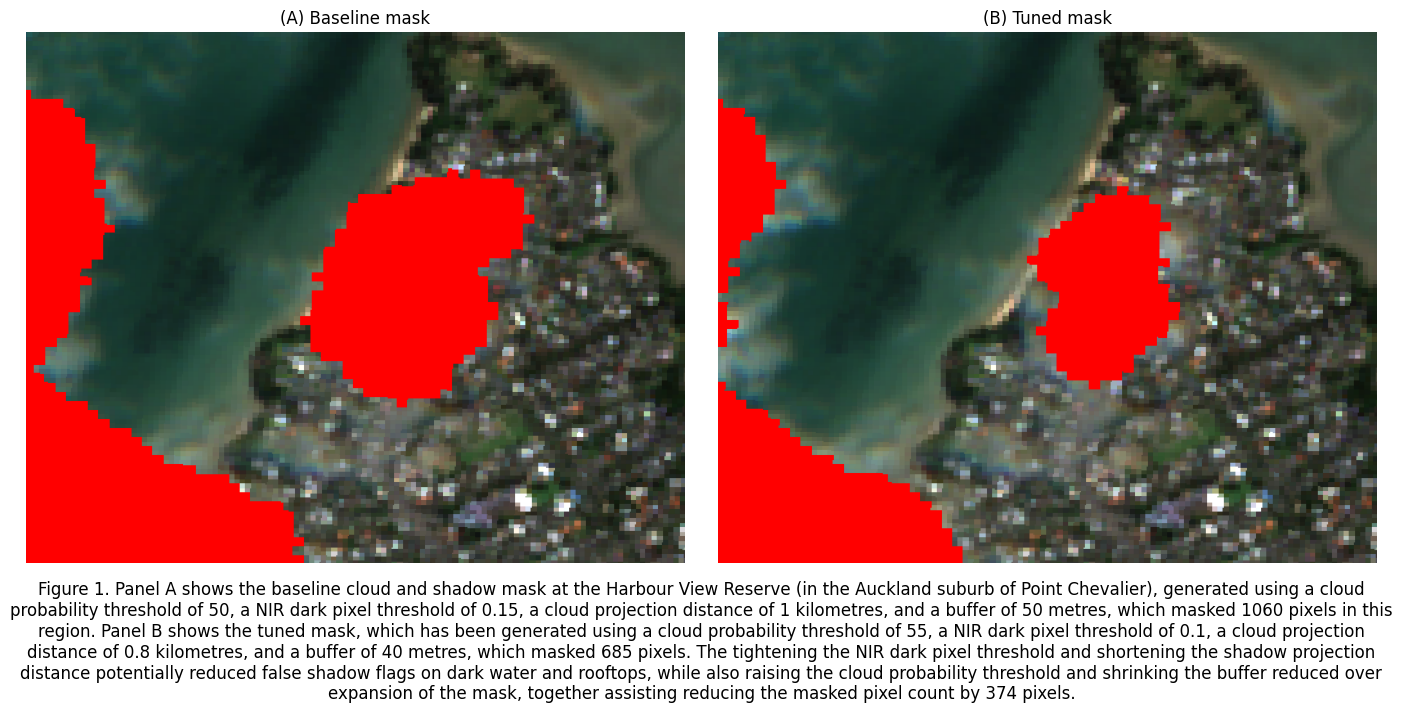

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [117]:
# Generating the RGB plus mask overlay thumbnails for both parameter sets, under the same coordinate area
baseline_img = get_mask_thumb(overlap_region_center, START_DATE, END_DATE, region_buffer_m=600, **baseline_params)
tuned_img = get_mask_thumb(overlap_region_center, START_DATE, END_DATE, region_buffer_m=600, **tuned_params)

# Setting up the 1x2 side by side figure for the before and after comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Left panel: baseline mask, labelled (A)
ax1.imshow(baseline_img)
ax1.set_title('(A) Baseline mask')
ax1.axis('off')

# Right panel: tuned mask, labelled (B)
ax2.imshow(tuned_img)
ax2.set_title('(B) Tuned mask')
ax2.axis('off')

# Adding following figure caption, which states both parameter sets, their masked pixel counts, and the reasoning behind the change, referencing panels (A) and (B) directly
caption = (
    f"Figure 1. Panel A shows the baseline cloud and shadow mask at the Harbour View Reserve (in the Auckland suburb of Point Chevalier), generated using a cloud probability "
    f"threshold of {baseline_params['cld_prb_thresh']}, a NIR dark pixel threshold of "
    f"{baseline_params['nir_drk_thresh']}, a cloud projection distance of {baseline_params['cld_prj_dist']} kilometres, "
    f"and a buffer of {baseline_params['buffer']} metres, which masked {baseline_count:.0f} pixels in this region. "
    f"Panel B shows the tuned mask, which has been generated using a cloud probability threshold of "
    f"{tuned_params['cld_prb_thresh']}, a NIR dark pixel threshold of {tuned_params['nir_drk_thresh']}, "
    f"a cloud projection distance of {tuned_params['cld_prj_dist']} kilometres, and a buffer of "
    f"{tuned_params['buffer']} metres, which masked {tuned_count:.0f} pixels. The tightening the NIR dark pixel "
    f"threshold and shortening the shadow projection distance potentially reduced false shadow flags on dark water "
    f"and rooftops, while also raising the cloud probability threshold and shrinking the buffer reduced "
    f"over expansion of the mask, together assisting reducing the masked pixel count by {(baseline_count - tuned_count):.0f} pixels."
)

# Reserving space below the axes for the caption, then placing it just under the images
plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
fig.text(0.5, 0.02, caption, wrap=True, ha='center', va='bottom', fontsize=12)

# Saving and displaying the figure
plt.savefig('cloud_mask_comparison_updated.png', dpi=200, bbox_inches='tight')
plt.show()

# Automatically downloading the saved figure
from google.colab import files
files.download('cloud_mask_comparison_updated.png')

## Reference link to the use of Axes array (ax1/ax2) = https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
## Reference link to the use of ":.of" function for rounding the pixel counts in the figure caption: https://stackoverflow.com/questions/26176611/string-formatting-d-vs-d-on-floating-point-number

Finally for this section, let's apply this cloud mask to our data and generate a 'cloud free' image. Replace my parameters used below with the ones you have selected based on your answer to question 2.

In [17]:
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [18]:
# Define a function to apply the cloud mask to the S2 spectral bands
def apply_cld_shdw_mask(img):
    cloudmask = img.select('cloudmask')
    # Mask cloudy pixels
    masked_img = img.updateMask(cloudmask.Not())
    # Keep cloudmask and probability bands
    cloudmask_band = img.select('cloudmask')
    probability_band = img.select('probability')
    masked_img = masked_img.addBands([cloudmask_band, probability_band], overwrite=True)
    return masked_img

In [19]:
# Process the collection
s2_sr_median = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .median())

In [20]:
# Display the cloud free composite
def display_cloud_free_mosaic(s2_sr_median, AOI):
    # Create a geemap Map object and center it on the AOI
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add the Sentinel-2 RGB mosaic
    m.addLayer(
        s2_sr_median,
        {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1},
        'S2 cloud-free mosaic')

    return m

display_map = display_cloud_free_mosaic(s2_sr_median, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Now THAT is a cloud-free image! (Well, with my thresholds we still have a little there over the SW forest, can yours do better?).

(3) This process has managed to avoid masking out the many bright white roofs of Auckland as cloud, despite them appearing very similar to cloud in the RGB visualization. How has the algorithm achieved this?
(5 pts)


________________________________________________________________________________

= Since the s2cloudless probability layer is extracted from a classifier trained under the Sentinel 2 spectral (visible through SWIR), not primarily the visual brightness, as bright rooftops and cloud can appear relatively similar white in an RGB (B4, B3, B2) composite, this is a particular human visualisation artifact that mainly uses 3 of the bands. The true cloud has a particular multispectral signature of high reflectance sustained into the SWIR bands, characteristic of water droplets or potential ice scattering. In contrast, rooftop materials do not replicate this, even with their visible brightness. This is primarily because the algorithm evaluates the full spectral profile rather than RGB brightness alone, as it can accurately distinguish spectrally cloud like pixels from bright but spectrally different surfaces like roofing.

# Extending S2 Cloudless with a clustering approach
The process we explored in the prior section has worked really rather well! But you saw in the exercise that it does rely on you setting the local paramaters. This is a manual process and one that is at risk of reduced effectiveness if we are clearing cloud over a wide area. This is particularly the case for cirrus and other thin clouds (e.g. cloud edges) that the thresholds are very sensitive to.

Therefore, let us extend our cloud-clearing algorithim into one that includes a clustering-step in which we sample the pixels around the edge of our clouds and test if they should be clustered into our cloud mask.

We will now implement the following workflow:
1.   Reset our data stack, with somewhat worse settings than the very good ones we have just set, in order to make this a better (for humans) teaching exercise.
2.   Define what counts as inside a cloud, outside a cloud and the edge of a cloud.
3.   Vizualize these samples and determine if we can perform meaningful clustering on them.
4.   Perform clustering of the border zone pixels with either the clouds or the cloud free.





In [21]:
# First, lets make our cloud clearing 'worse' in order to more clearly demonstrate our clustering alg
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 30
CLD_PRB_THRESH = 30
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 5

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

# Re-run s2cloudless approach, this time with .moasic as the compositing operator
s2_sr_mosaic = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .mosaic()) #<- switched to mosaic to better preserve the cloud masking layers we want to now use for our k-means workflow

In [22]:
def define_cloud_zones(img, edge_buffer=120):
    cloudmask = img.select('cloudmask')

    # Interior cloud pixels: cloudmask==1, away from edges (small erosion)
    cloud_interior = cloudmask.selfMask().focal_min(3)

    # Interior clear pixels: cloudmask==0, away from edges (medium erosion)
    clear_interior = cloudmask.Not().selfMask().focal_min(10)

    # Cloud edge pixels: buffer zone around clouds, but outside cloudmask
    cloud_edge = cloudmask.focal_max(edge_buffer / 10).And(cloudmask.Not())

    return cloud_interior, clear_interior, cloud_edge


In [23]:
def sample_zones(img, AOI, edge_buffer=20):
    cloudmask = img.select('cloudmask')

    cloud_interior = cloudmask.selfMask()
    clear_interior = cloudmask.Not().selfMask()
    cloud_edge = cloudmask.focal_max(edge_buffer).And(cloudmask.Not())

    sample_bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B9', 'B8', 'B11', 'B12']
    if 'probability' in img.bandNames().getInfo():
        sample_bands.append('probability')

    img_for_sampling = img.select(sample_bands)

    cloud_samples = img_for_sampling.updateMask(cloud_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=0, geometries=True)

    clear_samples = img_for_sampling.updateMask(clear_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=1, geometries=True)

    edge_samples = img_for_sampling.updateMask(cloud_edge).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=2, geometries=True)

    return cloud_samples, clear_samples, edge_samples


In [24]:
# Gather our samples
cloud_samples, clear_samples, edge_samples = sample_zones(s2_sr_mosaic, AOI)

# Function to convert a earth engine feature class to a pandas df
def fc_to_df(fc):
    features = fc.getInfo()['features']
    rows = []
    for f in features:
        props = f['properties']
        coords = f['geometry']['coordinates']
        props['longitude'] = coords[0]
        props['latitude'] = coords[1]
        rows.append(props)
    return pd.DataFrame(rows)


# Carry out the conversion and sanity print out what we have
cloud_df = fc_to_df(cloud_samples)
clear_df = fc_to_df(clear_samples)
edge_df = fc_to_df(edge_samples)

print(f"Cloud samples: {len(cloud_df)}")
print(f"Clear samples: {len(clear_df)}")
print(f"Edge samples: {len(edge_df)}")
print("Cloud columns:", cloud_df.columns)


Cloud samples: 727
Clear samples: 4310
Edge samples: 1930
Cloud columns: Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B8', 'B9', 'probability',
       'longitude', 'latitude'],
      dtype='object')


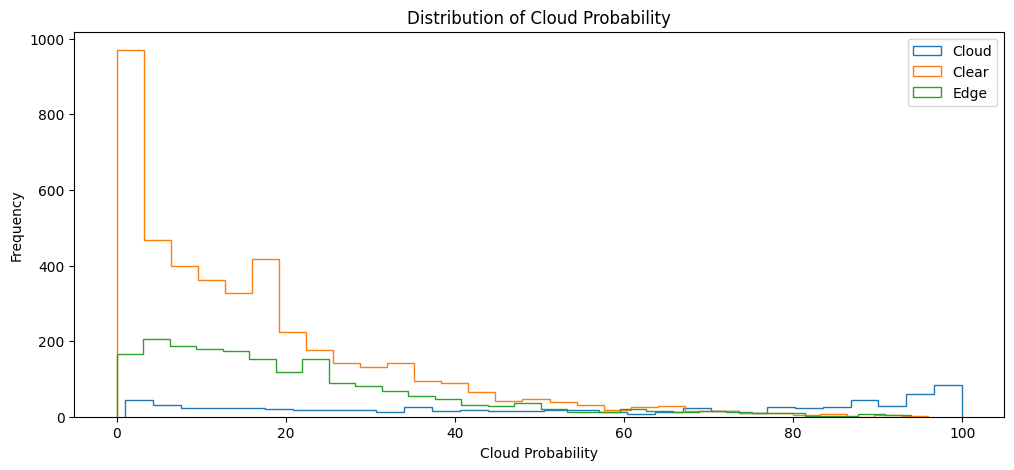

In [25]:
# Histogram of cloud probability by class
plt.figure(figsize=(12, 5))
plt.hist(cloud_df['probability'], bins=30, histtype='step', label='Cloud')
plt.hist(clear_df['probability'], bins=30, histtype='step', label='Clear')
plt.hist(edge_df['probability'], bins=30, histtype='step', label='Edge')
plt.xlabel('Cloud Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Cloud Probability')
plt.show()

Look at the histogram above. What is it telling you about the quality of the training classes you have just created? Think back to Lab 1, and the lecture 2/3 exercises.

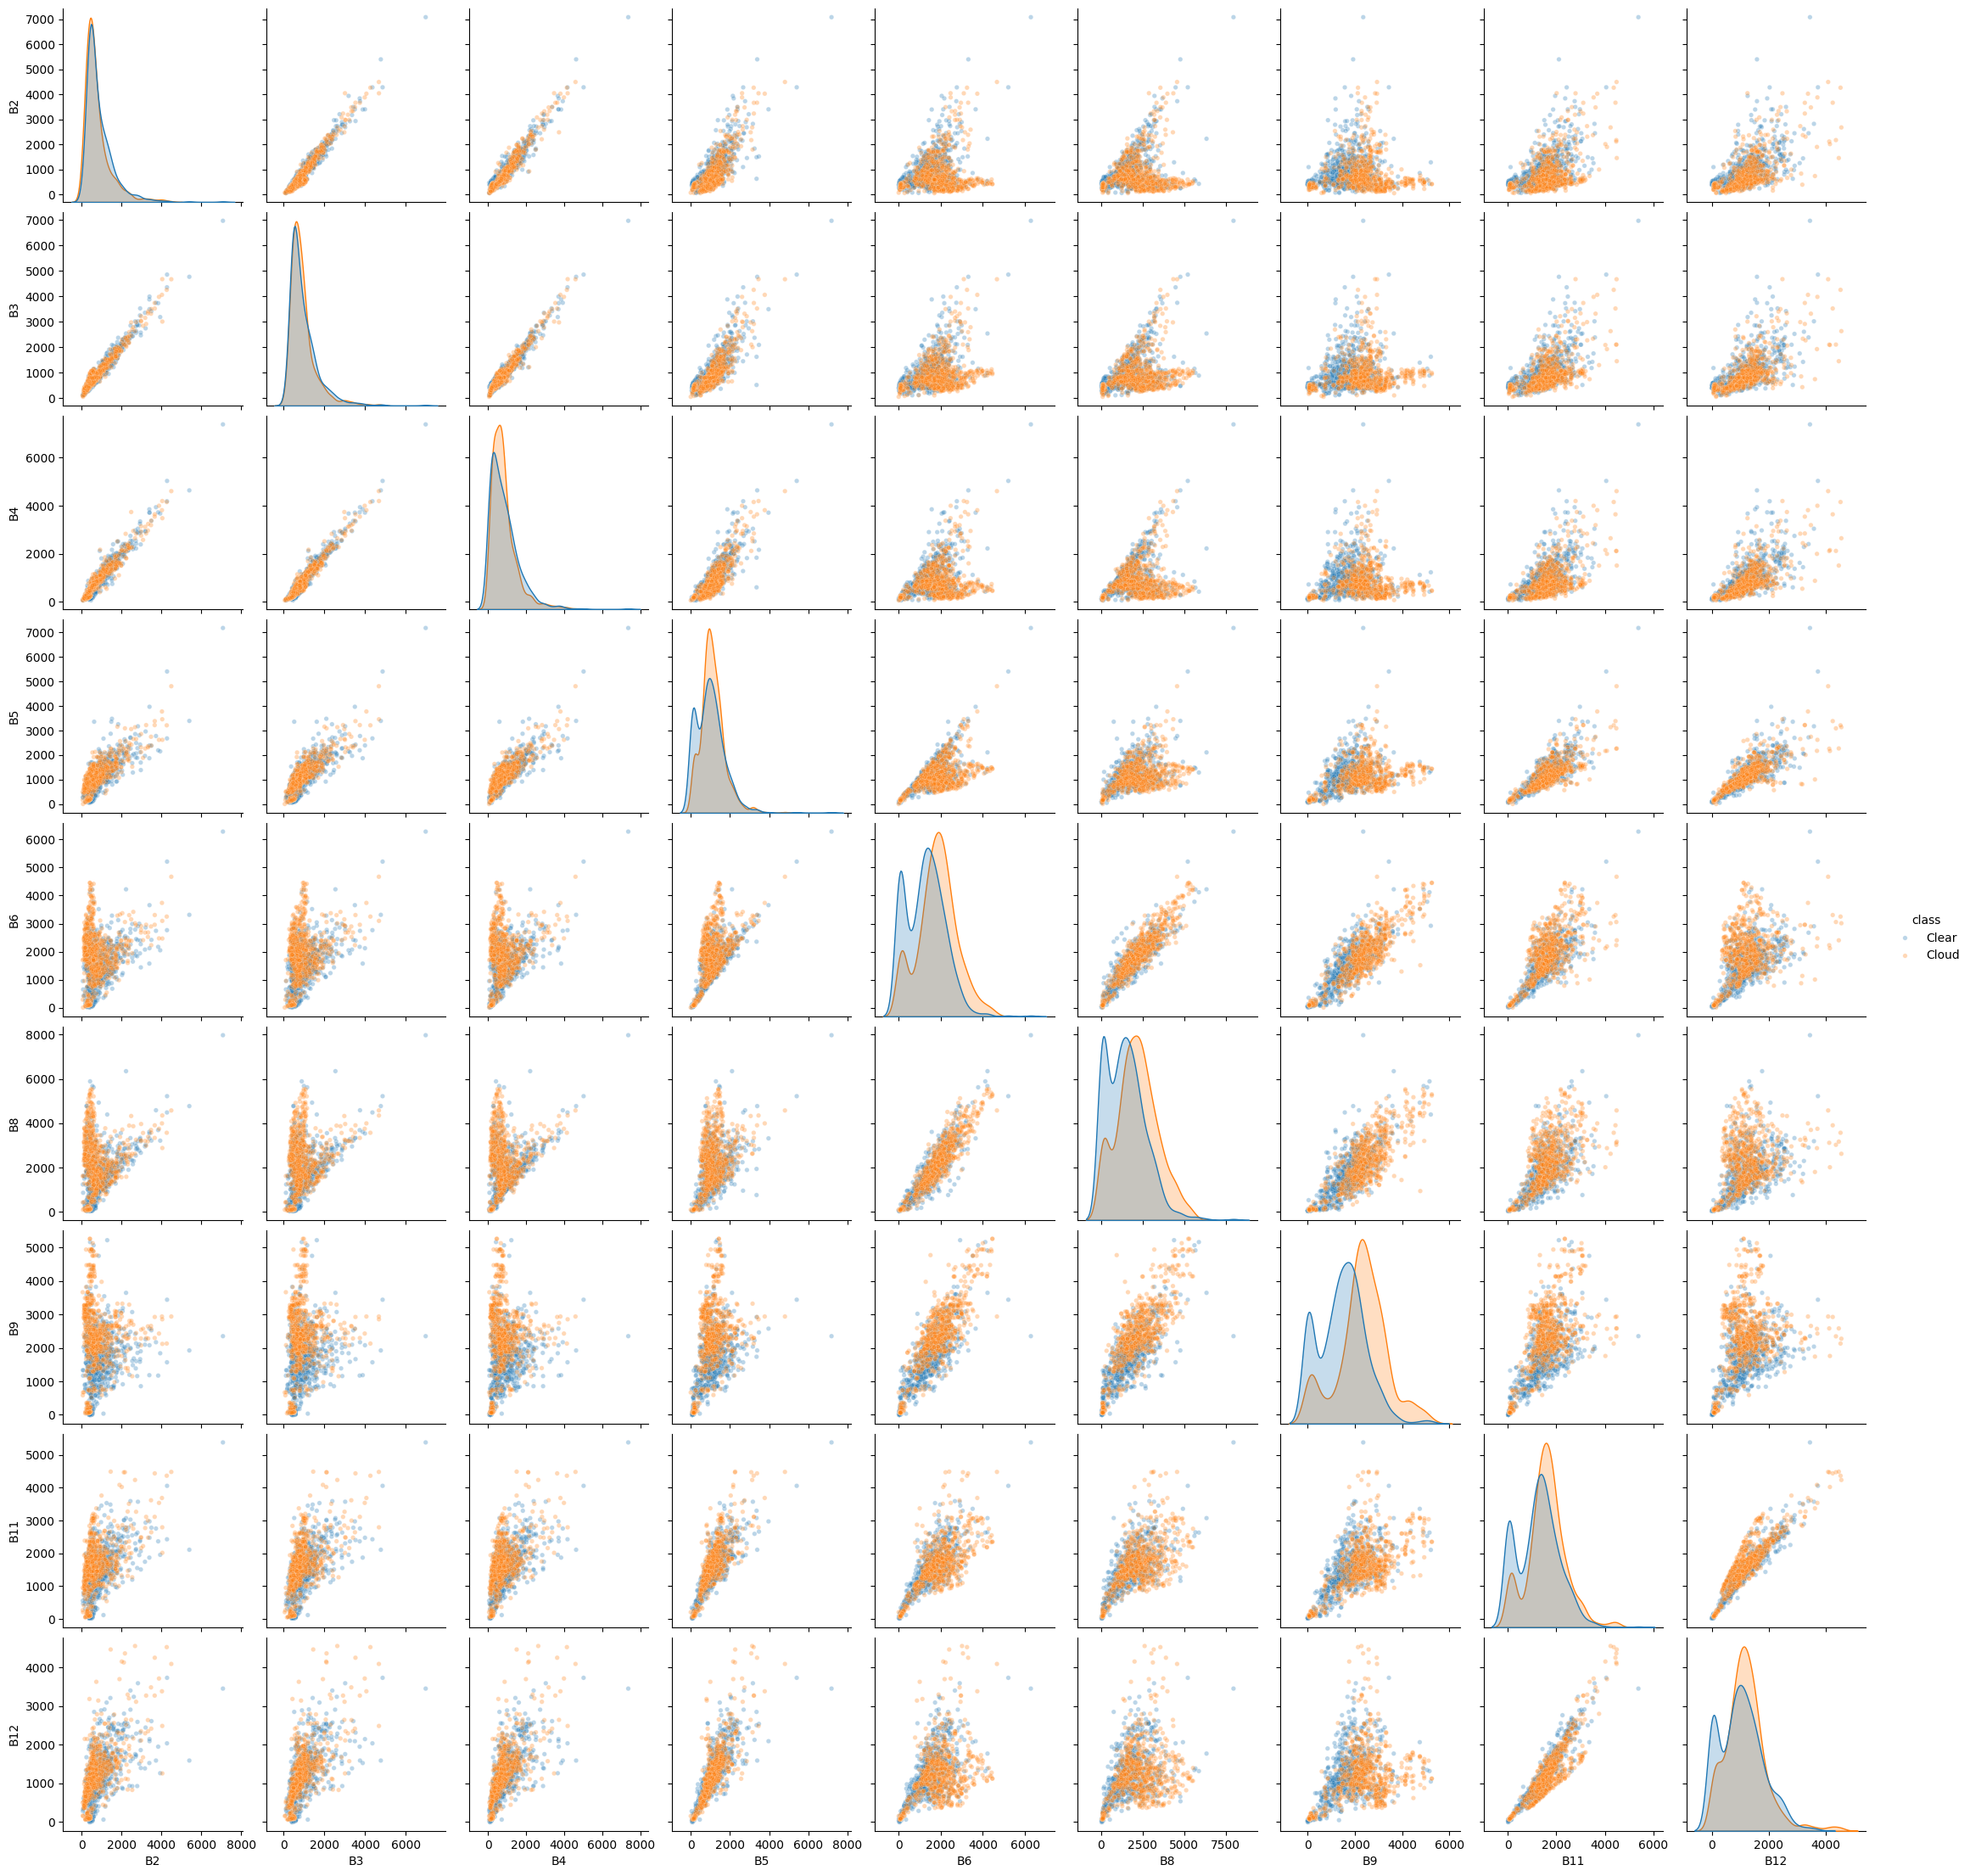

In [26]:
# Plot out all the bands, by the two 'labelled' classes that we want to discriminate between
# Add class labels
cloud_df['class'] = 'Cloud'
clear_df['class'] = 'Clear'

# Combine to one df
combined_df = pd.concat([cloud_df, clear_df])

# We will carry out somne class balancing here
# Find smallest class count
min_count = combined_df['class'].value_counts().min()

# Downsample each class to min_count
balanced_df = combined_df.groupby('class').sample(n=min_count, random_state=42)

# Now plot with balanced_df
# This is going to make a big plot that you will have to scroll around! Pay particular attention to the histogram plots on the diagonal.
bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B8', 'B9', 'B11', 'B12']
sns.pairplot(balanced_df, vars=bands, hue='class', plot_kws={'alpha':0.3, 's':15}, height=2.5)


(4) What do the histograms of cloud detection probability (as judged by s2cloudless) plotted in the three classes we have set here, AND the pair plot of all bands available tell us about our ability to tell cloudy vs non-cloud pixels apart? Make sure to explain your answer with reference to physical principles and the statistical foundations of ML (5 pts)


= The cloud probability histograms shows that the "clear" categroy class is detatched, while clustering tightly near a probability of zero, however the "cloud" category class is poorly separated where most of its samples are spread thinly across low to potentially mid probability values rather than clustering near 100, indicating s2cloudless itself is not sure that many of the labeled "cloud interior" pixels are actually cloud. Physically, this primarily reflects that the current mask settings (a low CLD_PRB_THRESH and only minimal erosion) include thin, marginal, or bordering cloud rather than pure, optically thick cloud cores, so the training class is spectrally polluted with pixels that resemble clear ground. This is confirmed in the pairplot shown above, where the category classes "Cloud" and "Clear" show heavily overlapping distributions in the visible bands (B2, B3, B4) but then become more separated and bimodal in B6, B8, B9, and B11. From a statistical Machine learning view, this represents a particular core principle: where a classifier is only as good as its training labels, and if the "cloud" and "clear" classes are not purely separable in feature space initially, no downstream clustering step can then be expected actually to draw a reliable decision boundary between them.

(5) Which bands are therefore going to be the best to use in our K-means clustering approach and why? (5 pts)

= Based on the generated pairplot, the possible best bands for K-means clustering are the ones showing the clearest separation between the "Cloud" and "Clear" classes on the diagonal histograms and in pairwise scatter plots, namely B8 (NIR), B9, and B11 (SWIR), rather than the default visible bands (B2, B3, B4), which show almost fully overlapping distributions for both classes. This choice is based on the same physical principle discussed in exercise 3, where clouds have a distinctive reflectance signature that persists into the NIR and SWIR ranges due to the way water droplets and ice scatter light. In contrast, many non-cloud bright or dark surfaces split from cloud in this part of the spectrum, even if they might look similar in the visible bands. Since K-means clusters purely on Euclidean distance in feature space with no inherent understanding of physical meaning, selecting bands where the two classes are already visibly separated (rather than overlapping) gives the algorithm the most reasonable chance of drawing a boundary that aligns with the true cloud and clear distinction, rather than a random split through a mixed, unclear region of feature space.

With our choices made, let us now test if we can implement k-means as a tool by which to assign those edge pixels into either the cloudy or clear classes. Noting that I have placed default band choices in the 'features to use for clustering' line. You do not need to use just three bands.

Run this section first with the default bands, and then change it to the ones you have selected in question 5. Observe the difference it makes...

In [89]:
# Use the balanced_df from before for cloud and clear pixels only
train_df = balanced_df[balanced_df['class'].isin(['Cloud', 'Clear'])]

# Features to use for clustering
features = ['B2', 'B3', 'B4']

# Prepare training data (cloud=1, clear=0)
X_train = train_df[features].values
y_train = (train_df['class'] == 'Cloud').astype(int).values

# Fit k-means with 2 clusters on training data
kmeans = KMeans(n_clusters=2, random_state=42).fit(X_train)

# Map clusters to classes by majority vote on training data
labels, counts = np.unique(kmeans.labels_[y_train==0], return_counts=True)
clear_cluster = labels[np.argmax(counts)]
labels, counts = np.unique(kmeans.labels_[y_train==1], return_counts=True)
cloud_cluster = labels[np.argmax(counts)]

# Prepare edge pixels data for prediction
edge_features = edge_df[features].values

# Predict clusters for edge pixels
edge_clusters = kmeans.predict(edge_features)

# Assign class labels to edge pixels based on cluster
edge_df['predicted_class'] = ['Cloud' if c == cloud_cluster else 'Clear' for c in edge_clusters]

# Quick summary
print(edge_df['predicted_class'].value_counts())


predicted_class
Cloud    1512
Clear     418
Name: count, dtype: int64


And now plot up the results of this below. Play around with this plotting and take a look at each set of band combinations you have chosen. Think about where the boundary is being placed, does it make sense?

predicted_class
Cloud    1512
Clear     418
Name: count, dtype: int64


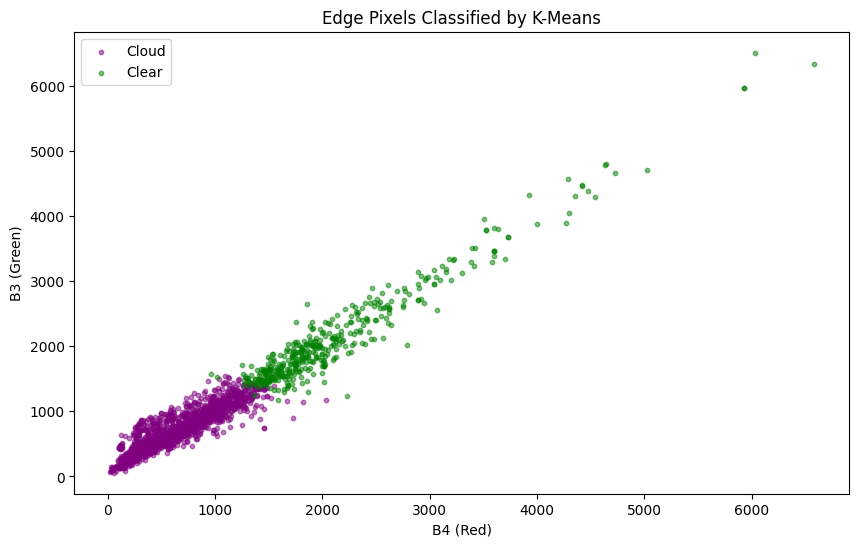

In [90]:
# Count of predicted classes
counts = edge_df['predicted_class'].value_counts()
print(counts)

# Scatter plot of edge pixels B4 vs B3 colored by predicted class ### CHANGE THIS TO YOUR OTHER BANDS ###
plt.figure(figsize=(10, 6))
for label, color in zip(['Cloud', 'Clear'], ['purple', 'green']):
    subset = edge_df[edge_df['predicted_class'] == label]
    plt.scatter(subset['B4'], subset['B3'], label=label, alpha=0.5, s=10, c=color)

plt.xlabel('B4 (Red)')
plt.ylabel('B3 (Green)')
plt.title('Edge Pixels Classified by K-Means')
plt.legend()
plt.show()


Finally, we will map this back onto earth engine via the following workflow:
1.  Export the classified edge pixels back to Earth Engine as a FeatureCollection
2. Rasterize the classified edge points into an image layer
3. Visualize refined cloud mask in Earth Engine (geemap):

Export to Earth Engine FC:

In [91]:
# Function to go the other way! This time from a dataframe to the feature collection
def df_to_ee_fc(df):
    features = []
    for _, row in df.iterrows():
        geom = ee.Geometry.Point([row['longitude'], row['latitude']])
        props = {k: float(row[k]) for k in ['B2', 'B3', 'B4', 'B8', 'probability']}
        props['predicted_class'] = row['predicted_class']
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)

edge_fc = df_to_ee_fc(edge_df)

Rasterize into image layer:

In [92]:
# Map predicted class to numeric
def class_to_numeric(feature):
    cls = feature.get('predicted_class')
    return feature.set('cloud_refined', ee.Number(ee.Algorithms.If(ee.String(cls).equals('Cloud'), 1, 0)))

edge_fc_num = edge_fc.map(class_to_numeric)

# Rasterize: paint 'cloud_refined' on a blank image
refined_cloud_mask = edge_fc_num.reduceToImage(
    properties=['cloud_refined'],
    reducer=ee.Reducer.first())

# Optionally, you can combine this refined mask with your existing cloudmask for a final refined mask
final_mask = s2_sr_median.select('cloudmask').max(refined_cloud_mask).rename('cloudmask_refined')


Visualize it:

In [93]:
Map = geemap.Map(basemap='HYBRID')
Map.centerObject(AOI, 12)

# Show original cloudmask
Map.addLayer(s2_sr_median.select('cloudmask'), {'palette': ['white', 'red']}, 'Original cloudmask')

# Show refined cloudmask
Map.addLayer(final_mask.selfMask(), {'palette': ['blue']}, 'Refined cloudmask')

Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Hopefully, what you should now see above is a patch of downtown Auckland that has your s2cloudless cloudmask and a scatter of blue pixels (i.e. the sample from within the AOI) that k-means has decided is cloud.

Your answer to Q5 should see this scatter of 'new cloudy' pixels be better associated with the known clouds than if you leave it as the default bands that I have provided.





(6) Exercise: take all you have learned in this lab and carry out the following improvements:
1. Increase the K-means sampling to be more representative of the whole scene. This means; sample regions for cloud, clear and cloud edge that are not just over downtown Auckland but from across multiple landcover types.
2. Take the model that you have trained here using SciKitLearn and use it to classify edge pixels across a whole satellite image.

Present your results in **two** figures. The first should show the results of upgrades to pt.1, the second the results of pt.2.

(15 pts)

To get you started on item 2, this might be how you plan out your workflow given that you cannot upload a python ML model directly to Earth Engine:
- Extract cluster centres from Python k-means.
- Pass centres as constants into EE.
- Write a per-pixel classification function assigning nearest cluster centre.
- Apply this function to edge pixels or the whole image as needed.

(PART 1 Answer to Exercise 6)

In [97]:
# Just doing initial steps of defining the varying landcover sample locations (including specifying coordinates)
sample_points = {
    'urban_downtown': ee.Geometry.Point(174.7633, -36.8485),
    'forest_waitakere': ee.Geometry.Point(174.5338, -36.9462),
    'farmland_pukekohe': ee.Geometry.Point(174.9020, -37.2000),
    'coastal_manukau': ee.Geometry.Point(174.8798, -36.9928),
    'harbour_gulf': ee.Geometry.Point(174.85, -36.621),
}

In [95]:
# Reassuring that the loop sample_zones() throughtout all the specified locations whilst also collecting results
all_cloud_dfs, all_clear_dfs, all_edge_dfs = [], [], [] # Empty lists to collect each regions samples

for name, point in sample_points.items():
    print(f"Sampling: {name}") # Using the progress indicator so than it can track which region is currently being processed
    # Rebuilding the cloud-masked mosaic centered on this point
    col = get_s2_sr_cld_col(point, START_DATE, END_DATE)
    # Rebuilding the cloud masked mosaic centered on this point
    mosaic = col.map(add_cld_shdw_mask).map(apply_cld_shdw_mask).mosaic() # Getting the S2 plus s2cloudless collection for this region
    cloud_samples, clear_samples, edge_samples = sample_zones(mosaic, point) # Applying the cloud and shadow mask and mosaic into one image

    c_df = fc_to_df(cloud_samples) # Converting the cloud FeatureCollection to a pandas DataFrame
    cl_df = fc_to_df(clear_samples) # Converting the clear FeatureCollection to a pandas DataFrame
    e_df = fc_to_df(edge_samples) # Converting the edge FeatureCollection to a pandas DataFrame

    # Tagging each row with its source region, so than comparisons can be made for old vs new later
    c_df['region'] = name
    cl_df['region'] = name
    e_df['region'] = name

    # Storing the regions cloud samples
    all_cloud_dfs.append(c_df)
    # Storing the regions clear samples
    all_clear_dfs.append(cl_df)
    # Storing the regions edge samples
    all_edge_dfs.append(e_df)

Sampling: urban_downtown
Sampling: forest_waitakere
Sampling: farmland_pukekohe
Sampling: coastal_manukau
Sampling: harbour_gulf


In [34]:
# Merging together into one multiple regional dataset
cloud_df_multi = pd.concat(all_cloud_dfs, ignore_index=True) # Combining all regions cloud samples into one DataFrame
clear_df_multi = pd.concat(all_clear_dfs, ignore_index=True) # Combining all regions clear samples into one DataFrame
edge_df_multi = pd.concat(all_edge_dfs, ignore_index=True) # Combining all regions edge samples into one DataFrame

print(f"Total cloud samples: {len(cloud_df_multi)}") # Sanity check on total sample counts
print(f"Total clear samples: {len(clear_df_multi)}") # Sanity check on total sample counts
print(f"Total edge samples: {len(edge_df_multi)}") # Sanity check on total sample counts
print(cloud_df_multi['region'].value_counts()) # Checking of how many cloud samples came from each region

Total cloud samples: 11175
Total clear samples: 13545
Total edge samples: 5093
region
farmland_pukekohe    4659
coastal_manukau      3489
forest_waitakere     2300
urban_downtown        727
Name: count, dtype: int64


In [35]:
# Balancing cloud samples across regions (not just across cloud and clear class)
min_region_count = cloud_df_multi['region'].value_counts().min() # Finding the smallest region sample count for cloud class
cloud_df_balanced = cloud_df_multi.groupby('region').sample(n=min_region_count, random_state=42) # Downsampling every region to match the smallest

min_region_count_clear = clear_df_multi['region'].value_counts().min() # Applying same balancing step but for the clear class
clear_df_balanced = clear_df_multi.groupby('region').sample(n=min_region_count_clear, random_state=42) # Downsampling every region to match the smallest

print("Balanced cloud samples per region:")
print(cloud_df_balanced['region'].value_counts()) # Confirming whether all regions now have equal representation

Balanced cloud samples per region:
region
coastal_manukau      727
farmland_pukekohe    727
forest_waitakere     727
urban_downtown       727
Name: count, dtype: int64


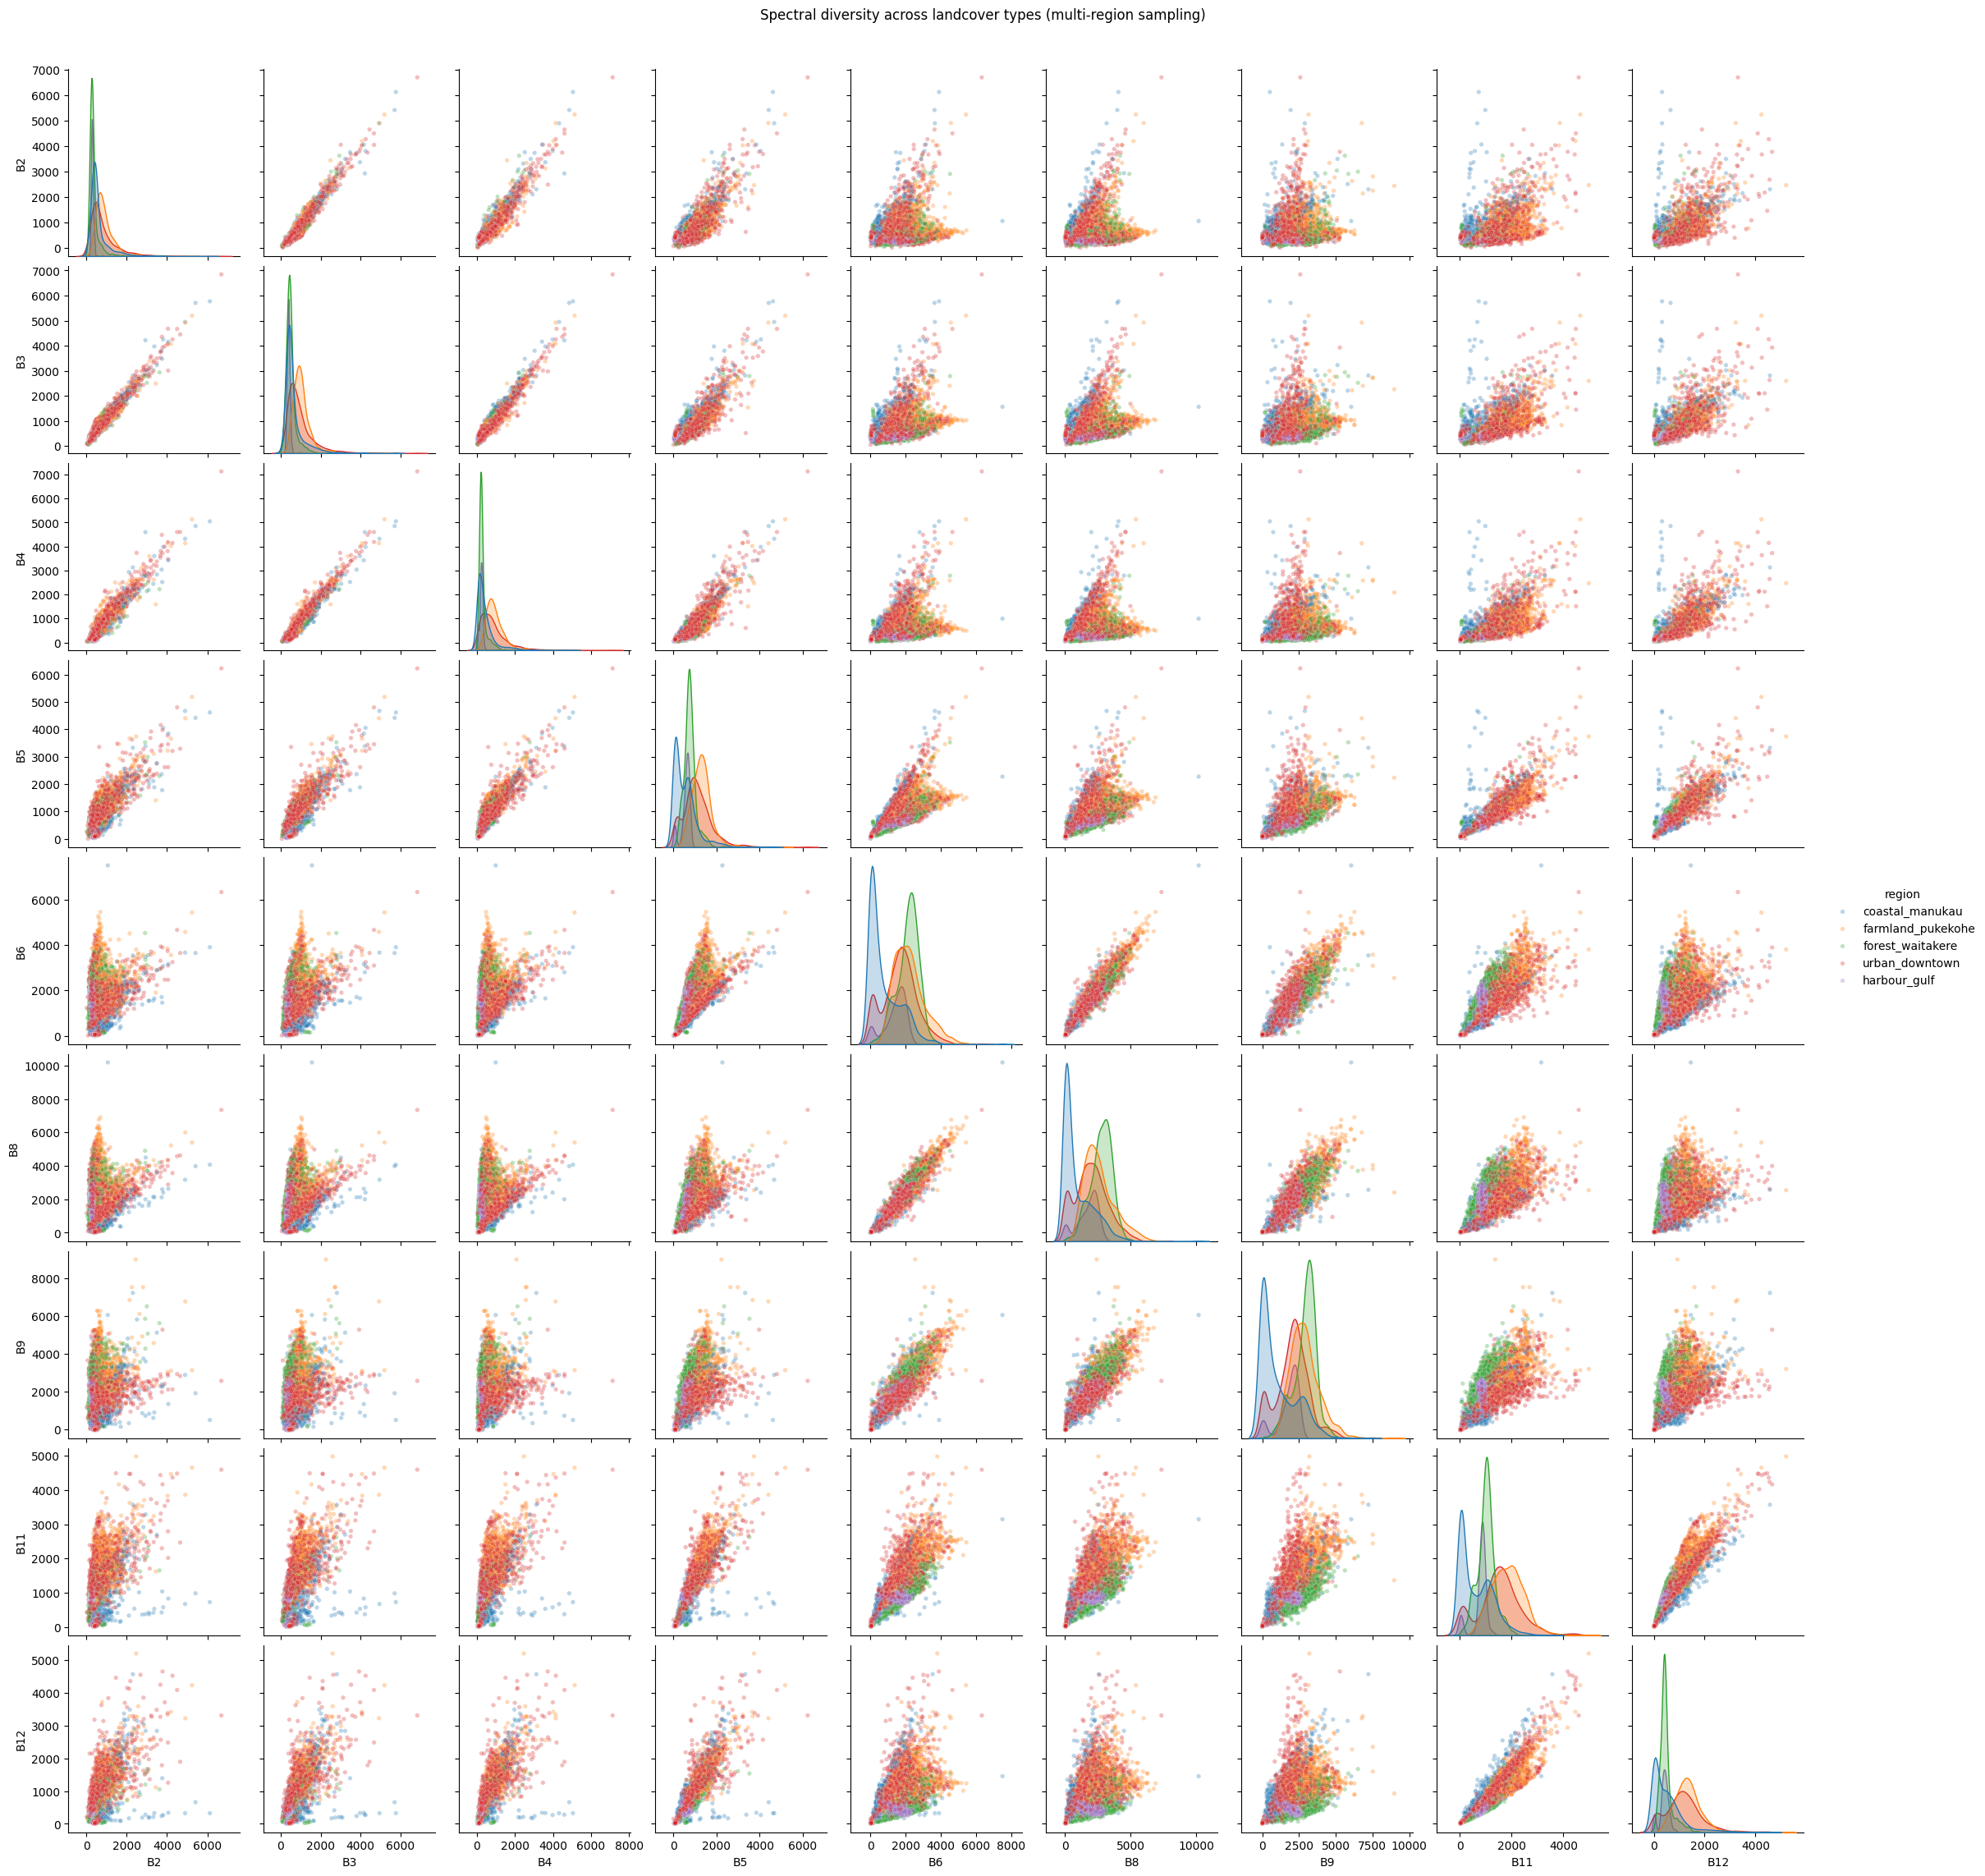

In [36]:
# Combining the balanced multiple-region cloud plus clear samples, tagged by region
cloud_df_balanced['class'] = 'Cloud' # Labelling cloud samples
clear_df_balanced['class'] = 'Clear' # Labelling clear samples

combined_multi_df = pd.concat([cloud_df_balanced, clear_df_balanced], ignore_index=True) # Merging both classes into one DataFrame

bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B8', 'B9', 'B11', 'B12'] # Specifying the spectral bands for visualization

# Generating a Pairplot colored by region, to show spectral diversity across landcover types
sns.pairplot(
    combined_multi_df,
    vars=bands, # Ploting these bands against each other
    hue='region', # Colouring points by their source region
    plot_kws={'alpha': 0.3, 's': 15}, # Making points semi transparent and small for readability purposes
    height=2.5
)
plt.suptitle('Spectral diversity across landcover types (multi-region sampling)', y=1.02)
plt.show()



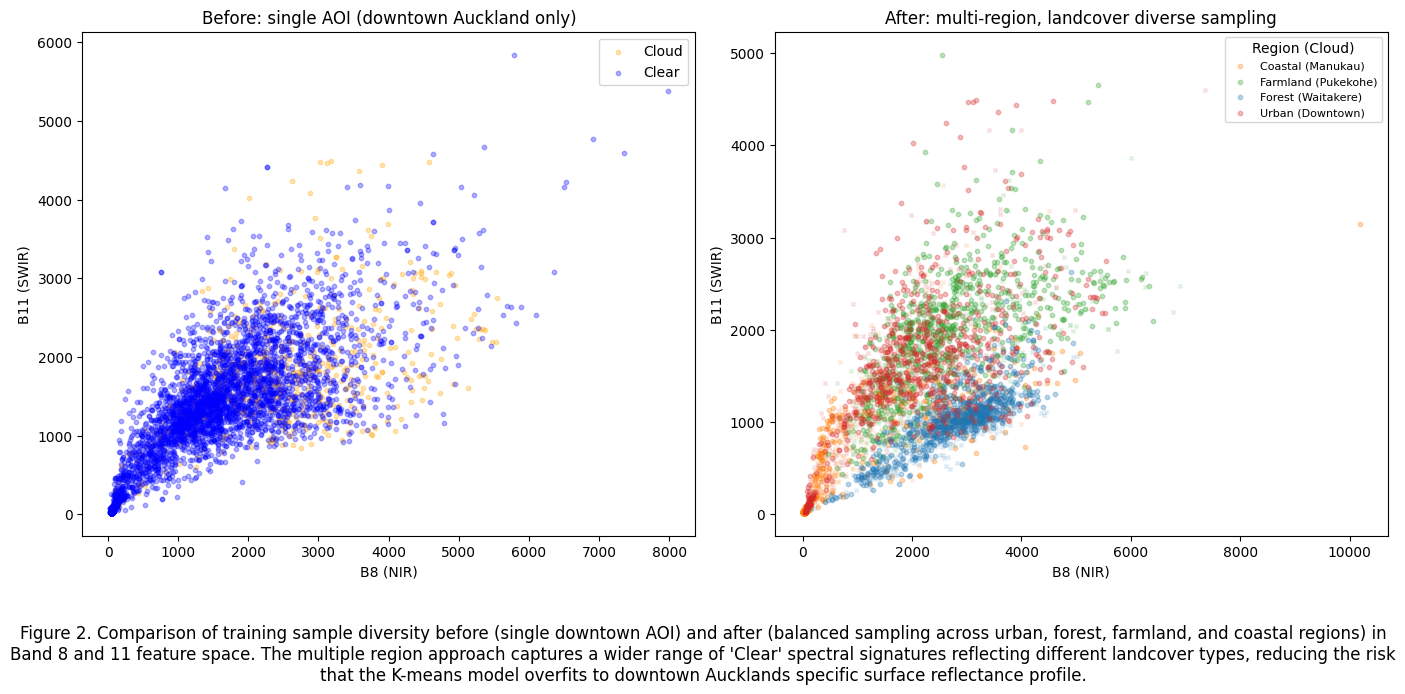

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [118]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))  # Setting up a 1x2 side-by-side figure

# BEFORE: original single-AOI (downtown only) samples
ax1.scatter(cloud_df['B8'], cloud_df['B11'], alpha=0.3, s=10, c='orange', label='Cloud')  # Plotting original downtown only cloud samples
ax1.scatter(clear_df['B8'], clear_df['B11'], alpha=0.3, s=10, c='blue', label='Clear')    # Plotting original downtown only clear samples
ax1.set_xlabel('B8 (NIR)')
ax1.set_ylabel('B11 (SWIR)')
ax1.set_title('Before: single AOI (downtown Auckland only)')
ax1.legend()

# Cleaning labels for the legend instead of the raw region keys
region_labels = {
    'urban_downtown': 'Urban (Downtown)',
    'forest_waitakere': 'Forest (Waitakere)',
    'farmland_pukekohe': 'Farmland (Pukekohe)',
    'coastal_manukau': 'Coastal (Manukau)',
    'harbour_gulf': 'Harbour/Gulf',
}

# AFTER: multiple-region, balanced samples
for region, color in zip(cloud_df_balanced['region'].unique(),
                          ['tab:orange', 'tab:green', 'tab:blue', 'tab:red']):  # Loopping through each region with a distinct colour
    subset_cloud = cloud_df_balanced[cloud_df_balanced['region'] == region]  # Isolating this regions cloud samples
    subset_clear = clear_df_balanced[clear_df_balanced['region'] == region]  # Isolating this regions clear samples
    label = region_labels.get(region, region)  # Looking up the cleaned display name for this region
    ax2.scatter(subset_cloud['B8'], subset_cloud['B11'], alpha=0.3, s=10, c=color, label=label)  # Plotting cloud samples for this region
    ax2.scatter(subset_clear['B8'], subset_clear['B11'], alpha=0.15, s=8, c=color, marker='x')  # Plotting clear samples for this region (marked with x, no legend clutter)

ax2.set_xlabel('B8 (NIR)')
ax2.set_ylabel('B11 (SWIR)')
ax2.set_title('After: multi-region, landcover diverse sampling')
ax2.legend(fontsize=8, title='Region (Cloud)')

# Adding the following caption to the figure
caption = (
    "Figure 2. Comparison of training sample diversity before (single downtown AOI) and after "
    "(balanced sampling across urban, forest, farmland, and coastal regions) in Band 8 and 11 feature "
    "space. The multiple region approach captures a wider range of 'Clear' spectral signatures "
    "reflecting different landcover types, reducing the risk that the K-means model overfits "
    "to downtown Aucklands specific surface reflectance profile."
)
fig.text(0.5, -0.05, caption, wrap=True, ha='center', va='top', fontsize=12)  # Add the figure caption below the plots

plt.tight_layout()
plt.savefig('figure2_multiregion_sampling.png', dpi=200, bbox_inches='tight')  # Save the figure to disk
plt.show() # displaying the figure plot

# Automatically downloading the saved figure
from google.colab import files
files.download('figure2_multiregion_sampling.png')

(PART 2 Answer to Exercise 6)

In [106]:
# Retraining the K-means using the multiple-region balanced samples, with the bands selected for best cloud and clear separability
features = ['B8', 'B9', 'B11']  # Bands used for giving the clearest cloud and clear separation

X_train_multi = combined_multi_df[features].values  # Feature matrix from the balanced multi-region samples
y_train_multi = (combined_multi_df['class'] == 'Cloud').astype(int).values  # 1 = Cloud, 0 = Clear

kmeans_multi = KMeans(n_clusters=2, random_state=42).fit(X_train_multi)  # Fitting K-means on the multi-region data

# Mapping each cluster to a class label by majority vote against the known training labels
labels, counts = np.unique(kmeans_multi.labels_[y_train_multi == 0], return_counts=True)
clear_cluster_multi = labels[np.argmax(counts)]  # Clustering index that mostly contains 'Clear' samples
labels, counts = np.unique(kmeans_multi.labels_[y_train_multi == 1], return_counts=True)
cloud_cluster_multi = labels[np.argmax(counts)]  # Clustering index that mostly contains 'Cloud' samples

# Viewing the following cluster outputs
print("Cluster centres (in feature order", features, "):")
print(kmeans_multi.cluster_centers_)
print(f"Cloud cluster index: {cloud_cluster_multi}, Clear cluster index: {clear_cluster_multi}")

Cluster centres (in feature order ['B8', 'B9', 'B11'] ):
[[2778.78661903 2925.33842157 1562.16141604]
 [ 691.84162378  863.28759291  570.00686106]]
Cloud cluster index: 0, Clear cluster index: 0


In [107]:
# Extract cluster centres from the retrained multi-region K-means model
cloud_centre = kmeans_multi.cluster_centers_[cloud_cluster_multi]  # Mean feature values of the 'Cloud' cluster
clear_centre = kmeans_multi.cluster_centers_[clear_cluster_multi]  # Mean feature values of the 'Clear' cluster

print("Cloud centre:", dict(zip(features, cloud_centre)))
print("Clear centre:", dict(zip(features, clear_centre)))

# Pass the centres into Earth Engine as constant images (one band per clustering feature)
cloud_centre_ee = ee.Image.constant(list(cloud_centre)).rename(features)  # Cloud centre as an EE constant image
clear_centre_ee = ee.Image.constant(list(clear_centre)).rename(features)  # Clear centre as an EE constant image

Cloud centre: {'B8': np.float64(2778.786619032134), 'B9': np.float64(2925.3384215654196), 'B11': np.float64(1562.1614160441968)}
Clear centre: {'B8': np.float64(2778.786619032134), 'B9': np.float64(2925.3384215654196), 'B11': np.float64(1562.1614160441968)}


In [108]:
# Per-pixel classification function assigning each pixel to its nearest cluster centre
def classify_nearest_centre(img):
    # Selecting only the bands used for clustering
    img_feats = img.select(features)

    # Computing the squared Euclidean distance from each pixel to the cloud centre
    dist_cloud = img_feats.subtract(cloud_centre_ee).pow(2).reduce(ee.Reducer.sum())
    # Computing the squared Euclidean distance from each pixel to the clear centre
    dist_clear = img_feats.subtract(clear_centre_ee).pow(2).reduce(ee.Reducer.sum())

    # The Pixel is classified as cloud (1) if it's closer to the cloud centre, else clear (0)
    kmeans_cloud = dist_cloud.lt(dist_clear).rename('kmeans_cloud')

    return img.addBands(kmeans_cloud)

In [109]:
# Applying the classification function across the whole AOI image (not just sampled edge points)
s2_sr_cld_col_full = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)  # Rebuilding the S2 plus s2cloudless collection for the AOI
s2_full_masked = s2_sr_cld_col_full.map(add_cld_shdw_mask)  # Applying the existing s2cloudless-based cloud and shadow mask
s2_full_classified = s2_full_masked.map(classify_nearest_centre).mosaic()  # Classifying every pixel, then mosaicing into one image

# Combining the original s2cloudless mask with the new K-means whole image classification
final_refined_mask = (
    s2_full_classified.select('cloudmask')
    .max(s2_full_classified.select('kmeans_cloud'))
    .rename('cloudmask_final')
)  # A pixel is marked cloud if EITHER method flags it

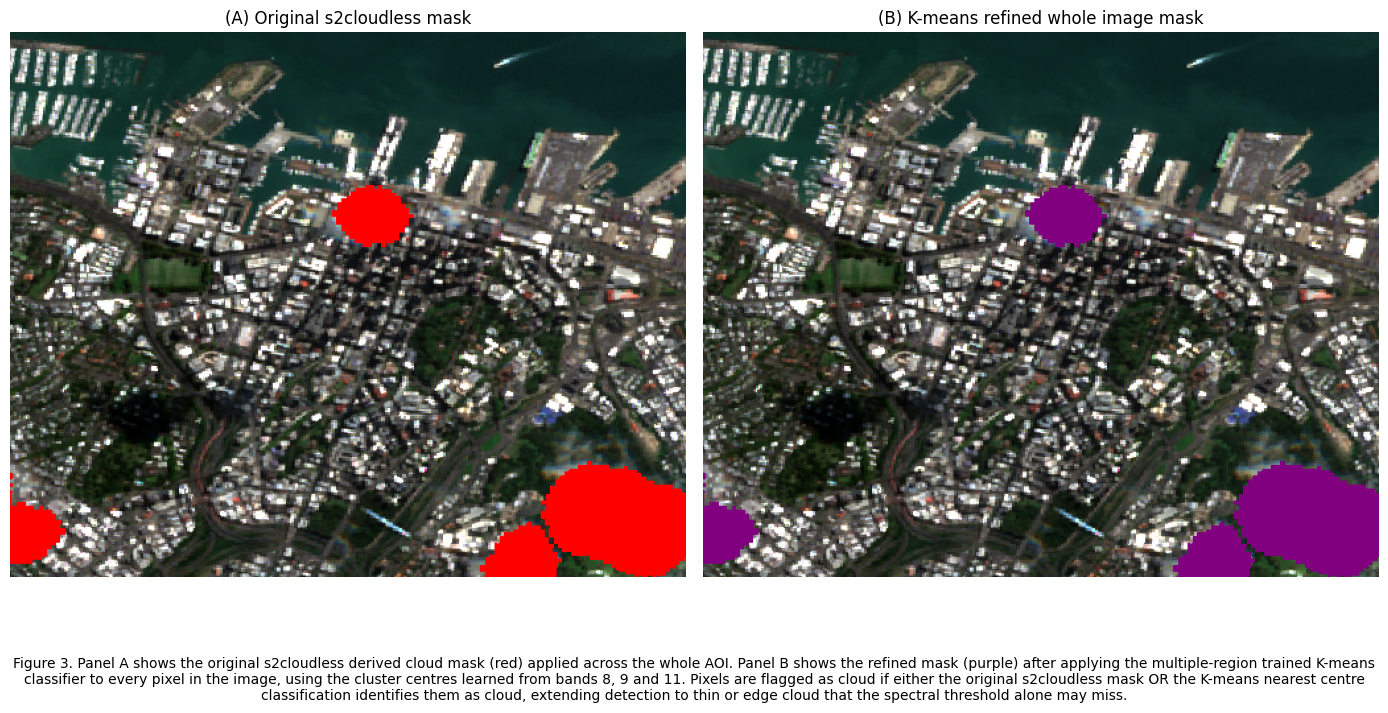

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [120]:
# Building the Figure 3, comparing the original s2cloudless mask against the K-means whole image classification
def get_classified_thumb(img, band, palette, region, dimensions=512):
    # Blends the true-colour RGB with a given mask band in a chosen colour, then fetches it as a PNG thumbnail
    rgb = img.select(['B4', 'B3', 'B2']).visualize(min=0, max=3000)
    mask_vis = img.select(band).selfMask().visualize(palette=palette)
    combined = rgb.blend(mask_vis)
    url = combined.getThumbURL({'region': region, 'dimensions': dimensions, 'format': 'png'})
    response = requests.get(url)
    return mpimg.imread(BytesIO(response.content), format='png')

region_full = AOI.buffer(1500).bounds()  # Applying the same buffer style used for earlier thumbnails

# Thumbnail A: original s2cloudless only cloud mask
orig_thumb = get_classified_thumb(s2_full_classified, 'cloudmask', ['red'], region_full)
# Thumbnail B: final refined mask (s2cloudless OR K-means)
refined_thumb = get_classified_thumb(s2_full_classified.addBands(final_refined_mask), 'cloudmask_final', ['purple'], region_full)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

ax1.imshow(orig_thumb)
ax1.set_title('(A) Original s2cloudless mask')
ax1.axis('off')

ax2.imshow(refined_thumb)
ax2.set_title('(B) K-means refined whole image mask')
ax2.axis('off')

# Adding the following caption to the figure
caption = (
    "Figure 3. Panel A shows the original s2cloudless derived cloud mask (red) applied across the "
    "whole AOI. Panel B shows the refined mask (purple) after applying the multiple-region trained "
    "K-means classifier to every pixel in the image, using the cluster centres learned from bands "
    f"8, 9 and 11. Pixels are flagged as cloud if either the original s2cloudless mask OR the K-means "
    "nearest centre classification identifies them as cloud, extending detection to thin or edge "
    "cloud that the spectral threshold alone may miss."
)
fig.text(0.5, 0.02, caption, wrap=True, ha='center', va='bottom', fontsize=10)

plt.tight_layout()
fig.subplots_adjust(bottom=0.2)
plt.savefig('figure3_kmeans_whole_image.png', dpi=200, bbox_inches='tight')
plt.show()

# Automatically downloading the saved figure
from google.colab import files
files.download('figure3_kmeans_whole_image.png')

